In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import norm
import matplotlib

import jax.numpy as jnp
from jax import config, random
import numpyro, jax
import numpyro.distributions as dist

from jnkepler.jaxttv import JaxTTV
from jnkepler.jaxttv import ttv_default_parameter_bounds, ttv_optim_curve_fit, scale_pdic
import corner
import pickle
import dill
import os
import pandas as pd

In [3]:
TESS_offset = 2457000

# Load data

In [4]:
with open('1339_jnkep_initial_fit_data.pkl', 'rb') as f:
    data = pickle.load(f)

popt = data['popt']
param_bounds = data['param_bounds']
jttv = data['jttv']

In [5]:

# file_name = '1339_jnkep_fit_1339-2000burn-4000step.pkl'
file_name = '1339_jnkep_fit_1339-2000burn-2000step-emax0.5.pkl'

# file_name = '1339_jnkep_fit_1339-1000burn-2000step.pkl'
# file_name = '1339_jnkep_fit_1339-100burn-200step.pkl'
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")

file_path = os.path.join(data_dir, file_name)

In [6]:
with open(file_name, "rb") as f:
    mcmc = dill.load(f)
mcmc.print_summary()
print(mcmc)


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.33      0.07      0.32      0.23      0.41     23.37      1.17
 ecosw_scaled[1]      0.35      0.06      0.35      0.27      0.43     23.05      1.17
 esinw_scaled[0]      0.36      0.09      0.35      0.24      0.51     57.53      1.08
 esinw_scaled[1]      0.38      0.08      0.37      0.28      0.51     56.57      1.08
period_scaled[0]      0.50      0.00      0.50      0.50      0.50    252.39      1.04
period_scaled[1]      0.50      0.00      0.50      0.50      0.50   1760.85      1.00
 pmass_scaled[0]      0.02      0.00      0.02      0.01      0.02    535.54      1.02
 pmass_scaled[1]      0.01      0.00      0.01      0.01      0.01   1292.86      1.01
   tic_scaled[0]      0.48      0.00      0.48      0.48      0.49    117.43      1.04
   tic_scaled[1]      0.51      0.01      0.51      0.50      0.52   2171.65      1.00

Number of divergences: 749


In [7]:
# Posterior samples
posterior_samples = mcmc.get_samples()

# Shape of samples
print({k: v.shape for k, v in posterior_samples.items()})


{'ecc': (8000, 2), 'ecosw': (8000, 2), 'ecosw_scaled': (8000, 2), 'ediff': (8000,), 'esinw': (8000, 2), 'esinw_scaled': (8000, 2), 'period': (8000, 2), 'period_scaled': (8000, 2), 'pmass': (8000, 2), 'pmass_scaled': (8000, 2), 'tcmodel': (8000, 39), 'tic': (8000, 2), 'tic_scaled': (8000, 2)}


# Plot models drawn from posteriors 

In [8]:
samples = mcmc.get_samples()

In [9]:
means, stds = jttv.sample_means_and_stds(samples, truncate=False)

/opt/homebrew/anaconda3/lib/python3.12/site-packages/jnkepler/jaxttv/jaxttv.py:523: UserWarning: using t0 and P from a linear fit to the observed transit times.
  warnings.warn(


<Figure size 1920x1440 with 0 Axes>

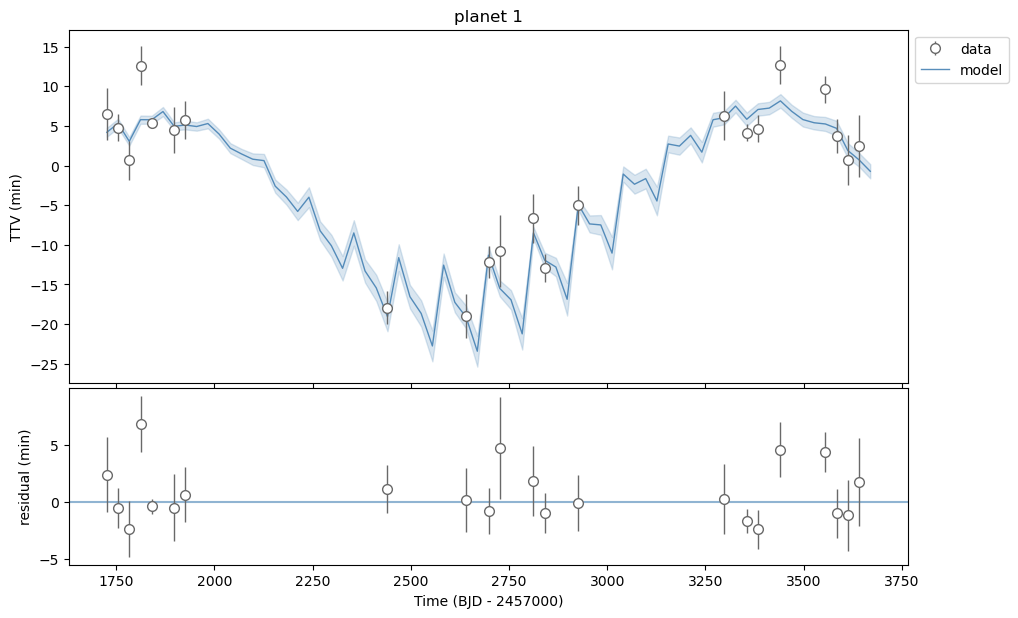

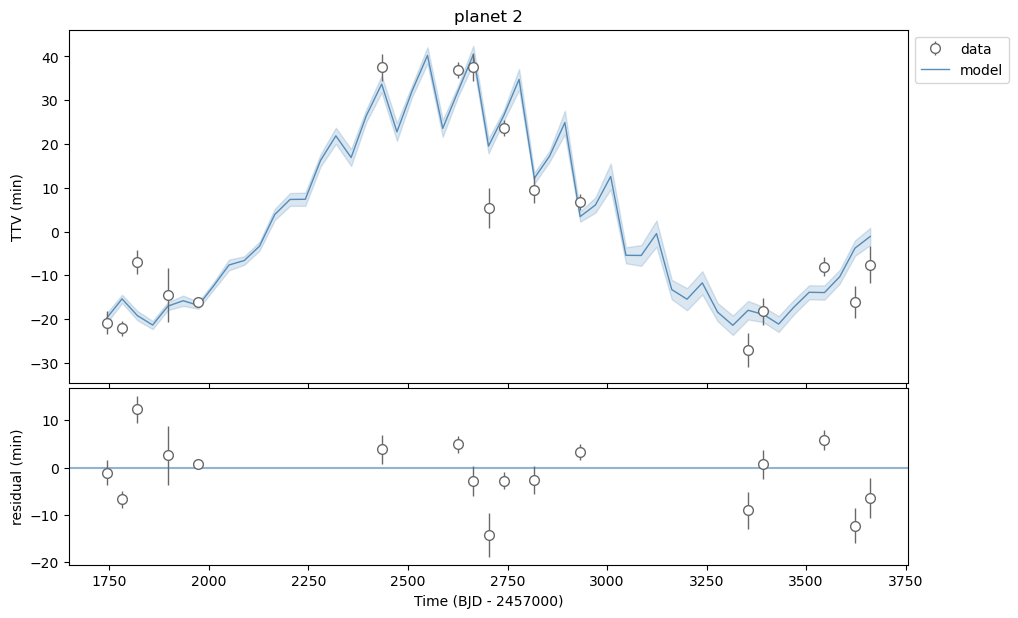

<Figure size 1920x1440 with 0 Axes>

In [10]:

jttv.plot_model(means, tcmodelunclist=stds, xlabel=f'Time (BJD - {TESS_offset})')
plt.figure(dpi=300) 

# Trace and corner plots

In [11]:
sample_keys = ["ecosw", "esinw", "pmass", "period", "tic"] # uniform mass prior

In [12]:
import arviz as az
idata = az.from_numpyro(mcmc)

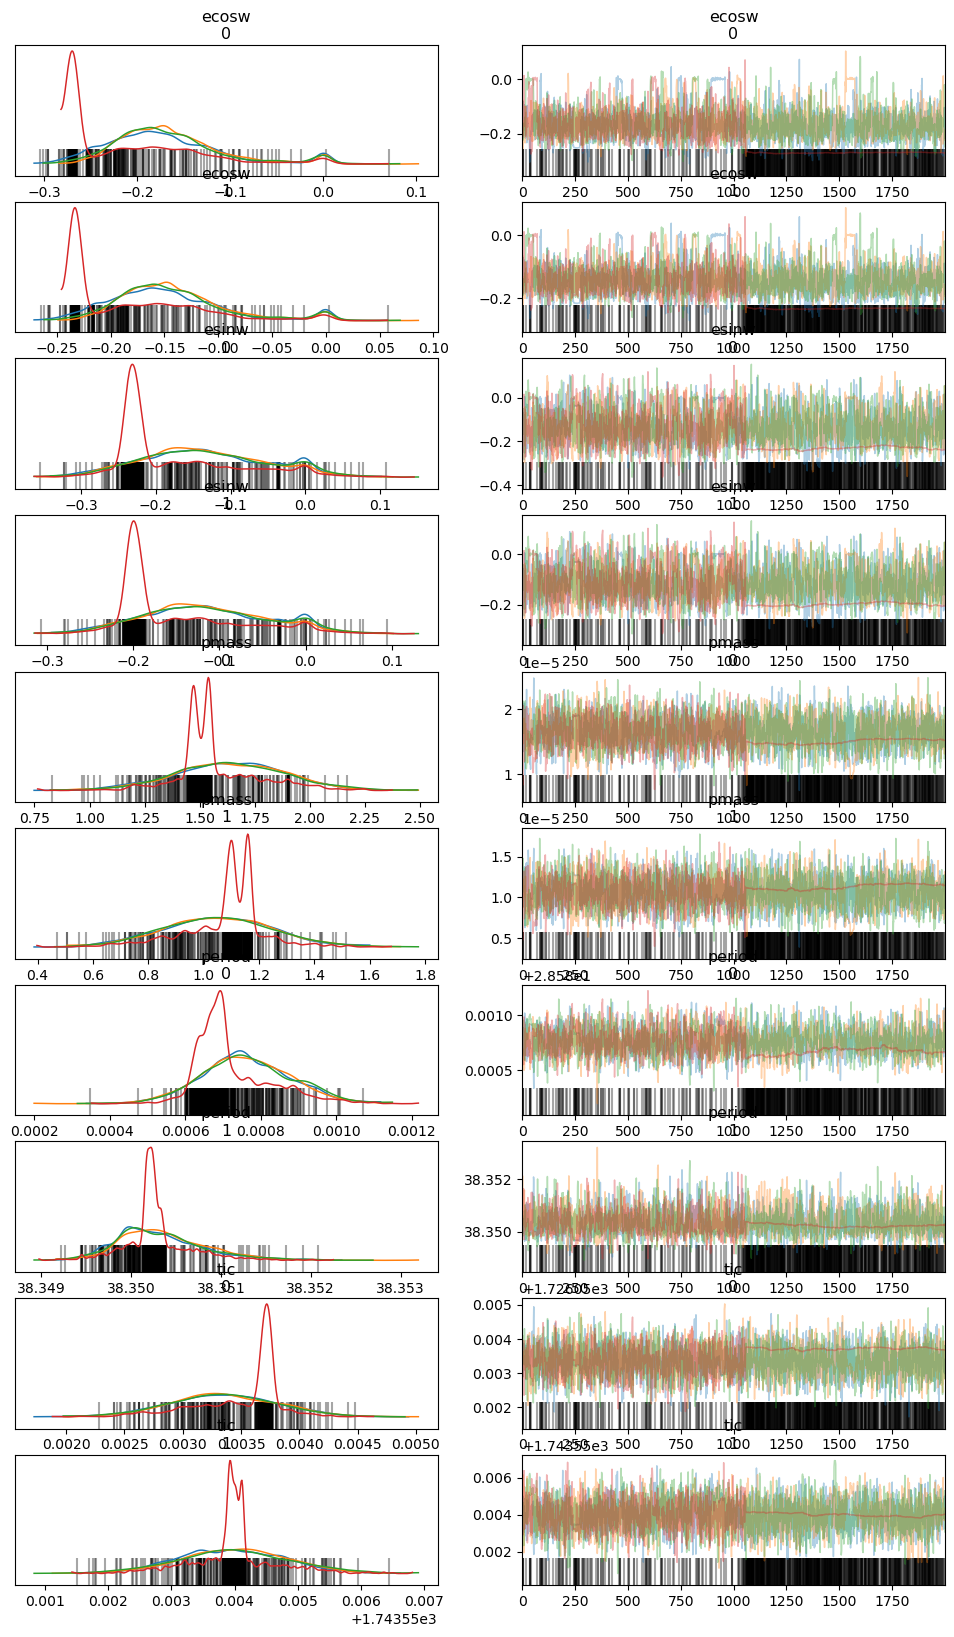

<Figure size 1920x1440 with 0 Axes>

In [13]:
# import arviz as az
# idata = az.from_numpyro(mcmc)
fig = az.plot_trace(mcmc, var_names=sample_keys, compact=False)
plt.figure(dpi=300) 
plt.tight_layout(pad=0.2)

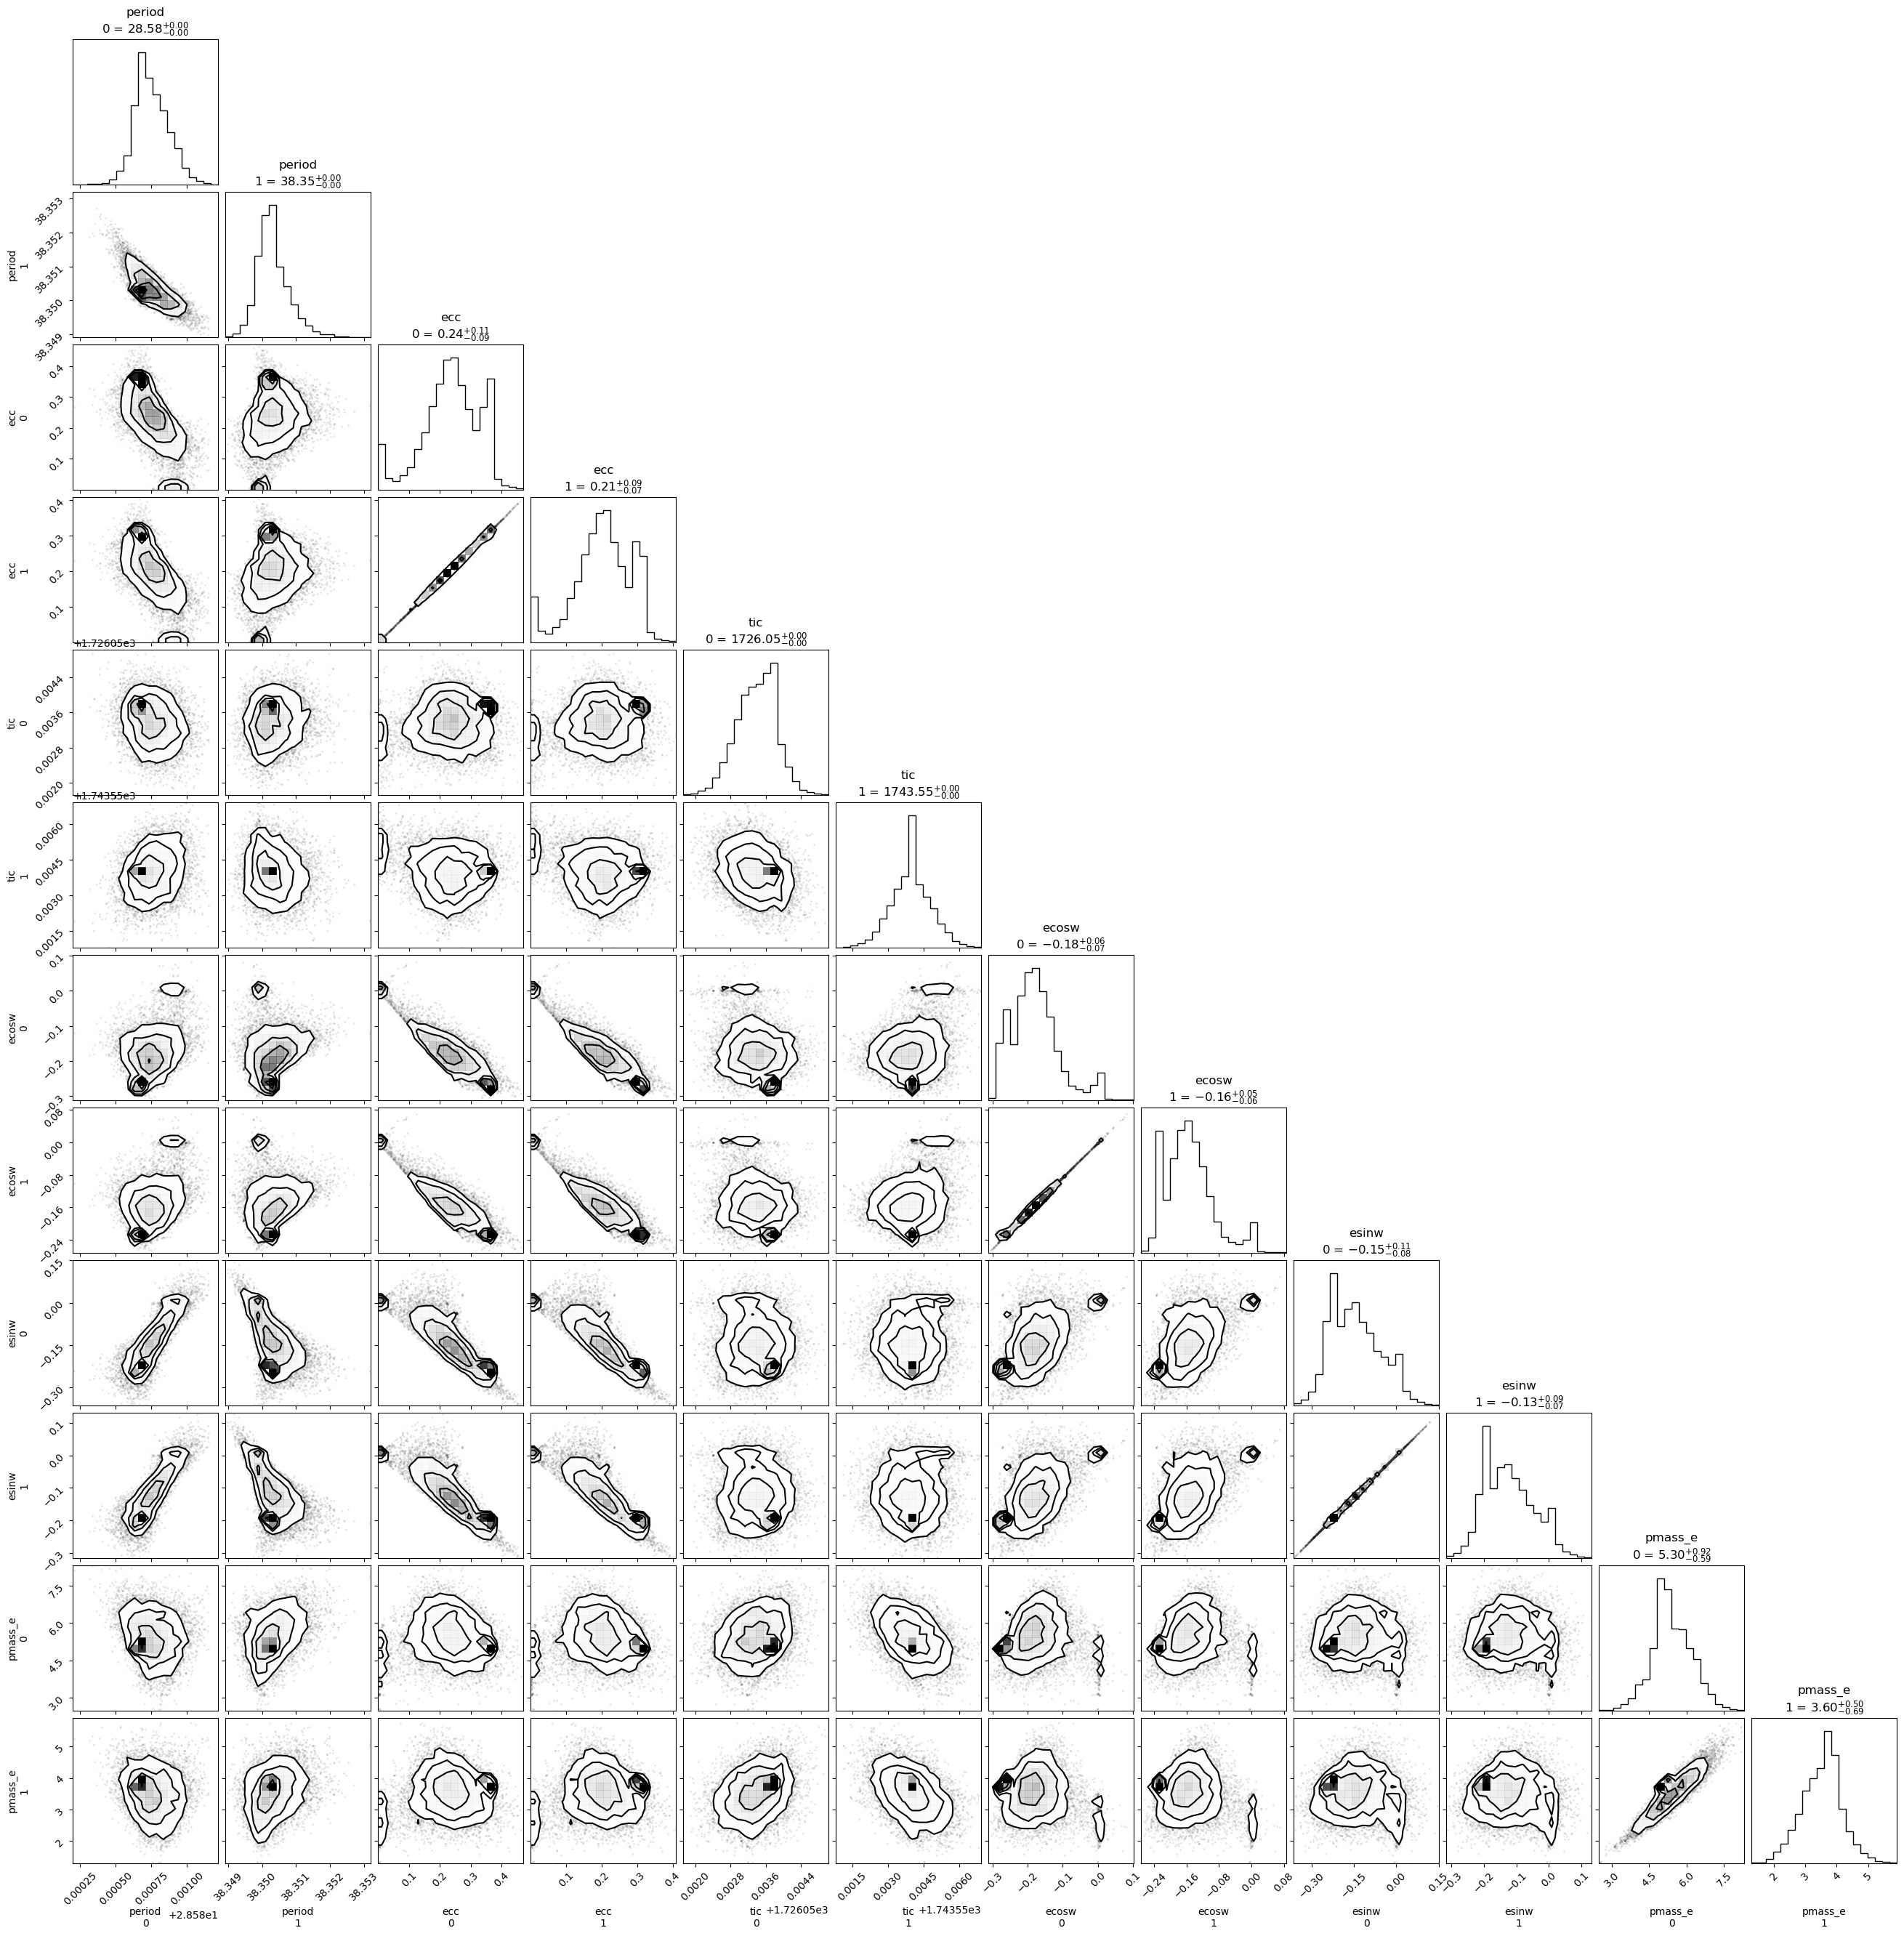

In [14]:
idata.posterior['pmass_e'] = idata.posterior['pmass'] / 3.003e-6
names = ["period", "ecc", "tic", "ecosw", "esinw", "pmass_e"]
fig = corner.corner(idata, var_names=names, show_titles=True)

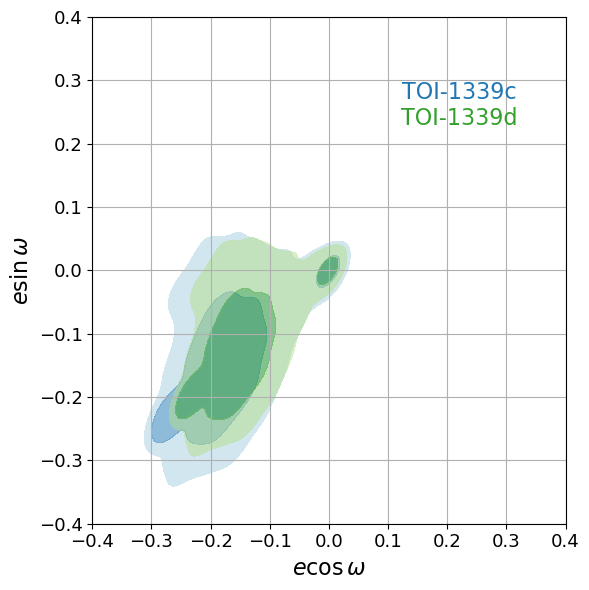

In [15]:
### 2D posterior for ecosw and esinw 
ecosw_b = samples["ecosw"][:, 0]
esinw_b = samples["esinw"][:, 0]

ecosw_c = samples["ecosw"][:, 1]
esinw_c = samples["esinw"][:, 1]

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde


def compute_kde_contour_levels(x, y, gridsize=100):
    data = np.vstack([x, y])
    kde = gaussian_kde(data)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    X, Y = np.mgrid[x_min:x_max:gridsize*1j, y_min:y_max:gridsize*1j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)
    return X, Y, Z, kde

def get_sigma_contour_levels(Z):
    Z_flat = Z.flatten()
    Z_sorted = np.sort(Z_flat)[::-1]
    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]
    levels = []
    for sigma in [0.683, 0.954]:
        idx = np.searchsorted(cumsum, sigma)
        levels.append(Z_sorted[idx])
    return sorted(levels)  # ensures ascending order

# Compute KDEs
Xb, Yb, Zb, kde_b = compute_kde_contour_levels(ecosw_b, esinw_b)
Xc, Yc, Zc, kde_c = compute_kde_contour_levels(ecosw_c, esinw_c)

# Get contour levels
levels_b = get_sigma_contour_levels(Zb)
levels_c = get_sigma_contour_levels(Zc)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Filled contours for planet b (blue shades)
ax.contourf(Xb, Yb, Zb, levels=levels_b + [Zb.max()], colors=['#a6cee3', '#1f78b4'], alpha=0.5)

# Filled contours for planet c (green shades)
ax.contourf(Xc, Yc, Zc, levels=levels_c + [Zc.max()], colors=['#b2df8a', '#33a02c'], alpha=0.5)

# Text annotation
ax.text(0.22, 0.27, 'TOI-1339c', color='#1f78b4', fontsize=16, ha='center')
ax.text(0.22, 0.23, 'TOI-1339d', color='#33a02c', fontsize=16, ha='center')


# Labels and legend
ax.set_xlabel(r"$e \cos\omega$", fontsize=16)
ax.set_ylabel(r"$e \sin\omega$", fontsize=16)
# ax.set_title("2D Joint Posterior of $e  cos(\omega)$ and $e sin(\omega)$")
blue_patch = plt.Line2D([], [], color='#a6cee3', label='Planet b')
red_patch = plt.Line2D([], [], color='#b2df8a', label='Planet c')
# ax.legend(handles=[blue_patch, red_patch])


# plt.grid(True)
plt.tick_params(axis='both', labelsize=13) 
plt.xlim(-0.40,0.40)
plt.ylim(-0.40,0.40)
plt.grid(True)
plt.tight_layout()
plt.show()

# Extracting values from posteriors 

In [16]:
### posterior samples 
ecosw_b = samples["ecosw"][:, 0]
esinw_b = samples["esinw"][:, 0]
Per_b = samples["period"][:,0] # [days]
Tc_b = samples["tic"][:,0] # [days]
pmass_b = samples["pmass"][:, 0] # [solar mass]

ecosw_c = samples["ecosw"][:, 1]
esinw_c = samples["esinw"][:, 1]
Per_c = samples["period"][:,1] # [days]
Tc_c = samples["tic"][:,1] # [days]
pmass_c = samples["pmass"][:, 1] # [solar mass]

### convert planet mass from solar to earth masses 
import astropy.constants as u
convert = (u.M_sun / u.M_earth).value
pmass_earth_b = pmass_b * convert
pmass_earth_c = pmass_c * convert


# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_b = np.sqrt(ecosw_b**2 + esinw_b**2)
omega_rad_b = np.arctan2(esinw_b, ecosw_b)
omega_deg_b = np.rad2deg(omega_rad_b)

# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_c = np.sqrt(ecosw_c**2 + esinw_c**2)
omega_rad_c = np.arctan2(esinw_c, ecosw_c)
omega_deg_c = np.rad2deg(omega_rad_c)


### keep Omega constant
value_Omega_b = 0  # [deg]
Omega_b = [np.radians(value_Omega_b)] * len(omega_rad_b)  # [rad]
value_Omega_c = 0 # [deg]
Omega_c = [np.radians(value_Omega_c)] * len(omega_rad_c)  # [rad]

pomega_rad_b = omega_rad_b + Omega_b
pomega_rad_c = omega_rad_c + Omega_c


Delta_omega_rad = omega_rad_c - omega_rad_b
Delta_omega_deg = omega_deg_c - omega_deg_b

In [17]:
def get_median_and_1sigma(samples):
    median = np.median(samples)
    lower = np.percentile(samples, 16)
    upper = np.percentile(samples, 84)
    return median, median - lower, upper - median


In [18]:
# Planet b
Per_b_med, Per_b_lo, Per_b_hi = get_median_and_1sigma(Per_b)
Tc_b_med, Tc_b_lo, Tc_b_hi = get_median_and_1sigma(Tc_b)
esinw_b_med, esinw_b_lo, esinw_b_hi = get_median_and_1sigma(esinw_b)
ecosw_b_med, ecosw_b_lo, ecosw_b_hi = get_median_and_1sigma(ecosw_b)
ecc_b_median, ecc_b_lo, ecc_b_hi = get_median_and_1sigma(ecc_b)
omega_deg_b_median, omega_deg_b_lo, omega_deg_b_hi = get_median_and_1sigma(omega_deg_b)
pmass_earth_b_median, pmass_earth_b_lo, pmass_earth_b_hi = get_median_and_1sigma(pmass_earth_b)

# Planet 
Per_c_med, Per_c_lo, Per_c_hi = get_median_and_1sigma(Per_c)
Tc_c_med, Tc_c_lo, Tc_c_hi = get_median_and_1sigma(Tc_c)
esinw_c_med, esinw_c_lo, esinw_c_hi = get_median_and_1sigma(esinw_c)
ecosw_c_med, ecosw_c_lo, ecosw_c_hi = get_median_and_1sigma(ecosw_c)
ecc_c_median, ecc_c_lo, ecc_c_hi = get_median_and_1sigma(ecc_c)
omega_deg_c_median, omega_deg_c_lo, omega_deg_c_hi = get_median_and_1sigma(omega_deg_c)
pmass_earth_c_median, pmass_earth_c_lo, pmass_earth_c_hi = get_median_and_1sigma(pmass_earth_c)

# Difference in omega
Delta_omega_deg_median, Delta_omega_deg_lo, Delta_omega_deg_hi = get_median_and_1sigma(Delta_omega_deg)


In [19]:
print(f"Period_b = {Per_b_med:.5f} (+{Per_b_hi:.5f}/-{Per_b_lo:.5f}) days")
print(f"Tc_b = {Tc_b_med:.5f} (+{Tc_b_hi:.5f}/-{Tc_b_lo:.5f}) days")
print(f"esinω_b = {esinw_b_med:.4f} (+{esinw_b_hi:.4f}/-{esinw_b_lo:.4f})")
print(f"ecosω_b = {ecosw_b_med:.4f} (+{ecosw_b_hi:.4f}/-{ecosw_b_lo:.4f})")
print(f"Ecc_b = {ecc_b_median:.3f} (+{ecc_b_hi:.3f}/-{ecc_b_lo:.3f})")
print(f"ω_b (deg) = {omega_deg_b_median:.1f} (+{omega_deg_b_hi:.1f}/-{omega_deg_b_lo:.1f})")
print(f"Mass_b (Earth) = {pmass_earth_b_median:.2f} (+{pmass_earth_b_hi:.2f}/-{pmass_earth_b_lo:.2f})")
print('\n')

print(f"Period_c = {Per_c_med:.5f} (+{Per_c_hi:.5f}/-{Per_c_lo:.5f}) days")
print(f"Tc_c = {Tc_c_med:.5f} (+{Tc_c_hi:.5f}/-{Tc_c_lo:.5f}) days")
print(f"esinω_c = {esinw_c_med:.4f} (+{esinw_c_hi:.4f}/-{esinw_c_lo:.4f})")
print(f"ecosω_c = {ecosw_c_med:.4f} (+{ecosw_c_hi:.4f}/-{ecosw_c_lo:.4f})")
print(f"Ecc_c = {ecc_c_median:.3f} (+{ecc_c_hi:.3f}/-{ecc_c_lo:.3f})")
print(f"ω_c (deg) = {omega_deg_c_median:.1f} (+{omega_deg_c_hi:.1f}/-{omega_deg_c_lo:.1f})")
print(f"Mass_c (Earth) = {pmass_earth_c_median:.2f} (+{pmass_earth_c_hi:.2f}/-{pmass_earth_c_lo:.2f})")
print('\n')

print(f"Δω (deg) = {Delta_omega_deg_median:.1f} (+{Delta_omega_deg_hi:.1f}/-{Delta_omega_deg_lo:.1f})")


Period_b = 28.58074 (+0.00013/-0.00010) days
Tc_b = 1726.05342 (+0.00035/-0.00048) days
esinω_b = -0.1530 (+0.1080/-0.0802)
ecosω_b = -0.1840 (+0.0624/-0.0666)
Ecc_b = 0.241 (+0.106/-0.085)
ω_b (deg) = -138.8 (+13.2/-13.7)
Mass_b (Earth) = 5.30 (+0.92/-0.59)


Period_c = 38.35025 (+0.00050/-0.00033) days
Tc_c = 1743.55398 (+0.00080/-0.00078) days
esinω_c = -0.1311 (+0.0929/-0.0696)
ecosω_c = -0.1582 (+0.0541/-0.0580)
Ecc_c = 0.207 (+0.092/-0.074)
ω_c (deg) = -138.9 (+13.2/-13.9)
Mass_c (Earth) = 3.59 (+0.50/-0.69)


Δω (deg) = -0.1 (+0.1/-0.1)


# Remove problematic chain

In [20]:
mcmc.print_summary()
posterior = mcmc.get_samples(group_by_chain=True)  # shape: (num_chains, num_samples, ...)
print({k: v.shape for k, v in posterior.items()})


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.33      0.07      0.32      0.23      0.41     23.37      1.17
 ecosw_scaled[1]      0.35      0.06      0.35      0.27      0.43     23.05      1.17
 esinw_scaled[0]      0.36      0.09      0.35      0.24      0.51     57.53      1.08
 esinw_scaled[1]      0.38      0.08      0.37      0.28      0.51     56.57      1.08
period_scaled[0]      0.50      0.00      0.50      0.50      0.50    252.39      1.04
period_scaled[1]      0.50      0.00      0.50      0.50      0.50   1760.85      1.00
 pmass_scaled[0]      0.02      0.00      0.02      0.01      0.02    535.54      1.02
 pmass_scaled[1]      0.01      0.00      0.01      0.01      0.01   1292.86      1.01
   tic_scaled[0]      0.48      0.00      0.48      0.48      0.49    117.43      1.04
   tic_scaled[1]      0.51      0.01      0.51      0.50      0.52   2171.65      1.00

Number of divergences: 749
{'ecc': (4, 20

In [21]:
good_chain_idxs = [0,1,2]

samples_filtered = {
    k: v[good_chain_idxs, ...] for k, v in posterior.items()
}
# print(samples_filtered)
samples_flat = {
    k: v.reshape(-1, *v.shape[2:]) for k, v in samples_filtered.items()
}


In [22]:
means, stds = jttv.sample_means_and_stds(samples_flat, truncate=False)

/opt/homebrew/anaconda3/lib/python3.12/site-packages/jnkepler/jaxttv/jaxttv.py:523: UserWarning: using t0 and P from a linear fit to the observed transit times.
  warnings.warn(


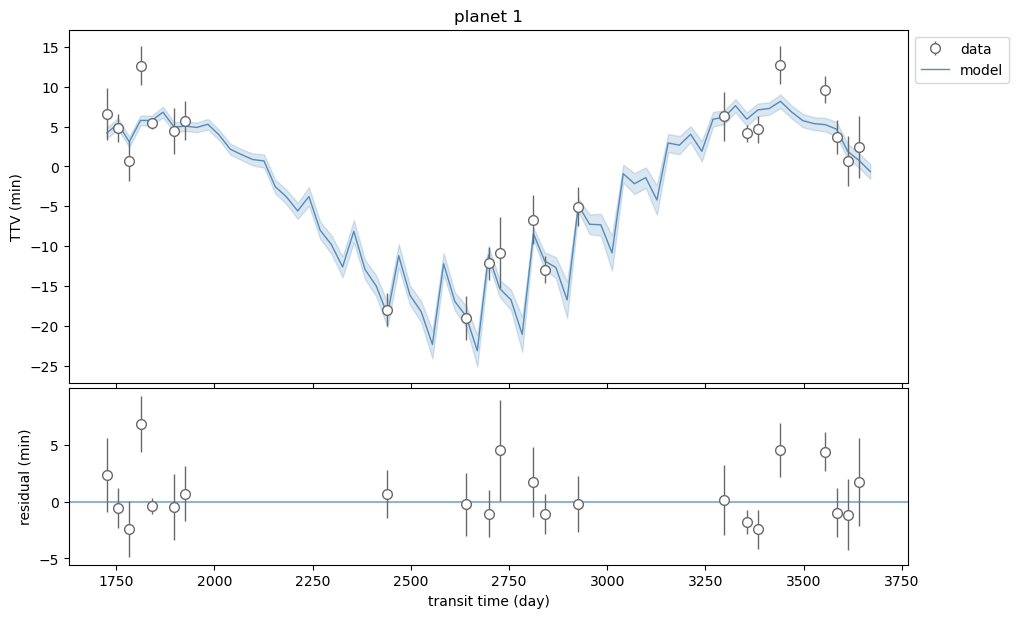

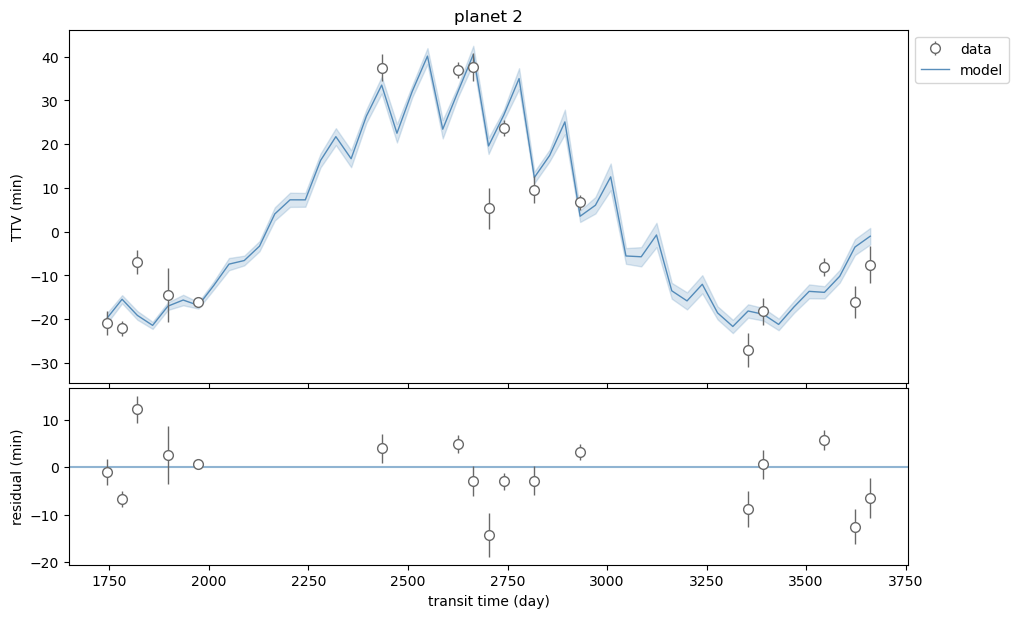

In [23]:
jttv.plot_model(means, tcmodelunclist=stds)

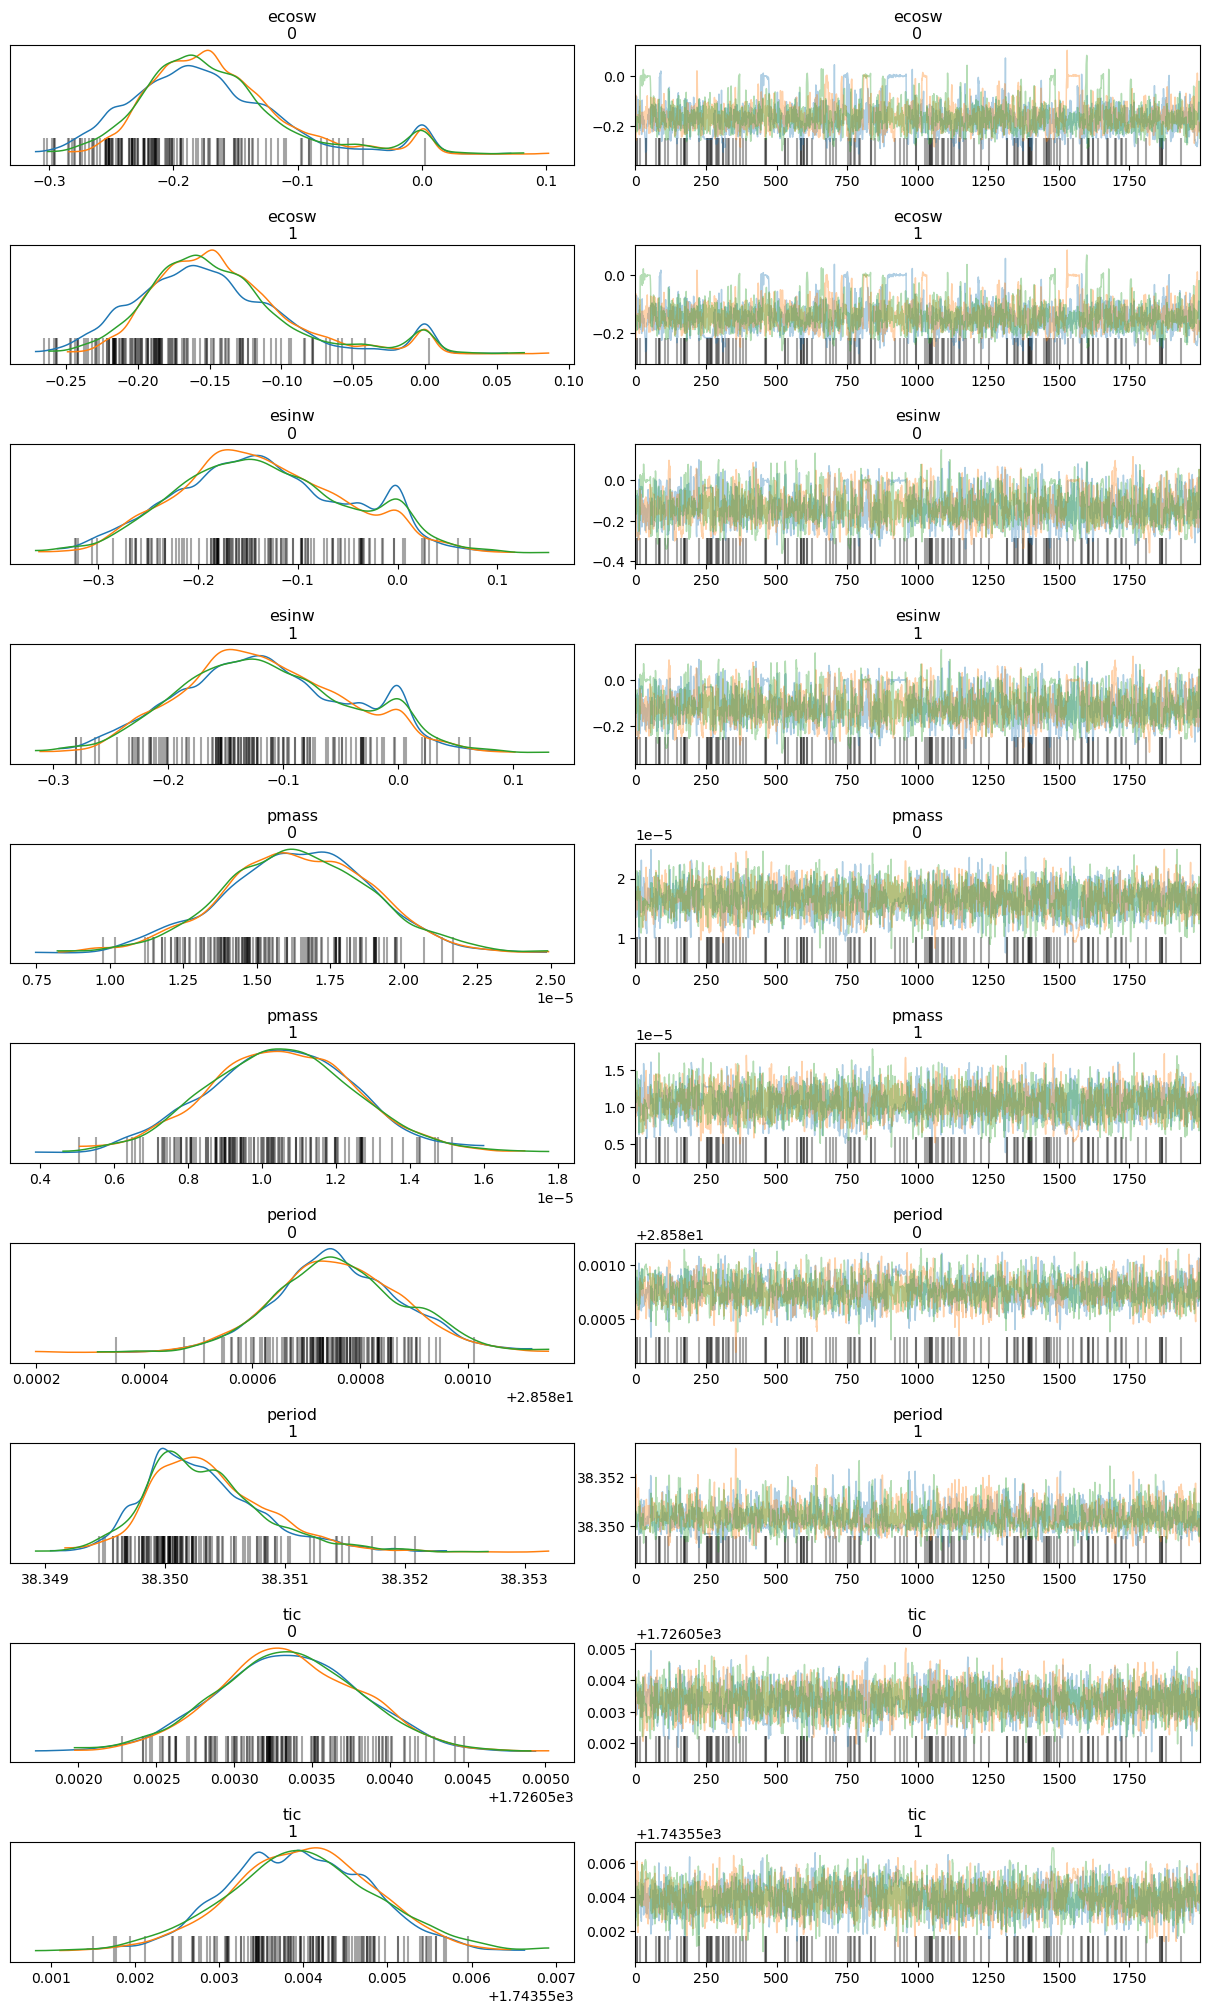

In [24]:
### remove outlier
az.summary(idata, var_names=sample_keys)
# Drop chain 1 from all groups that have 'chain' as a dimension
idata_filtered = idata.sel(chain=[c for c in idata.posterior.chain.values if c != 3])
az.plot_trace(idata_filtered, var_names=sample_keys, compact=False)
plt.tight_layout(pad=0.2)

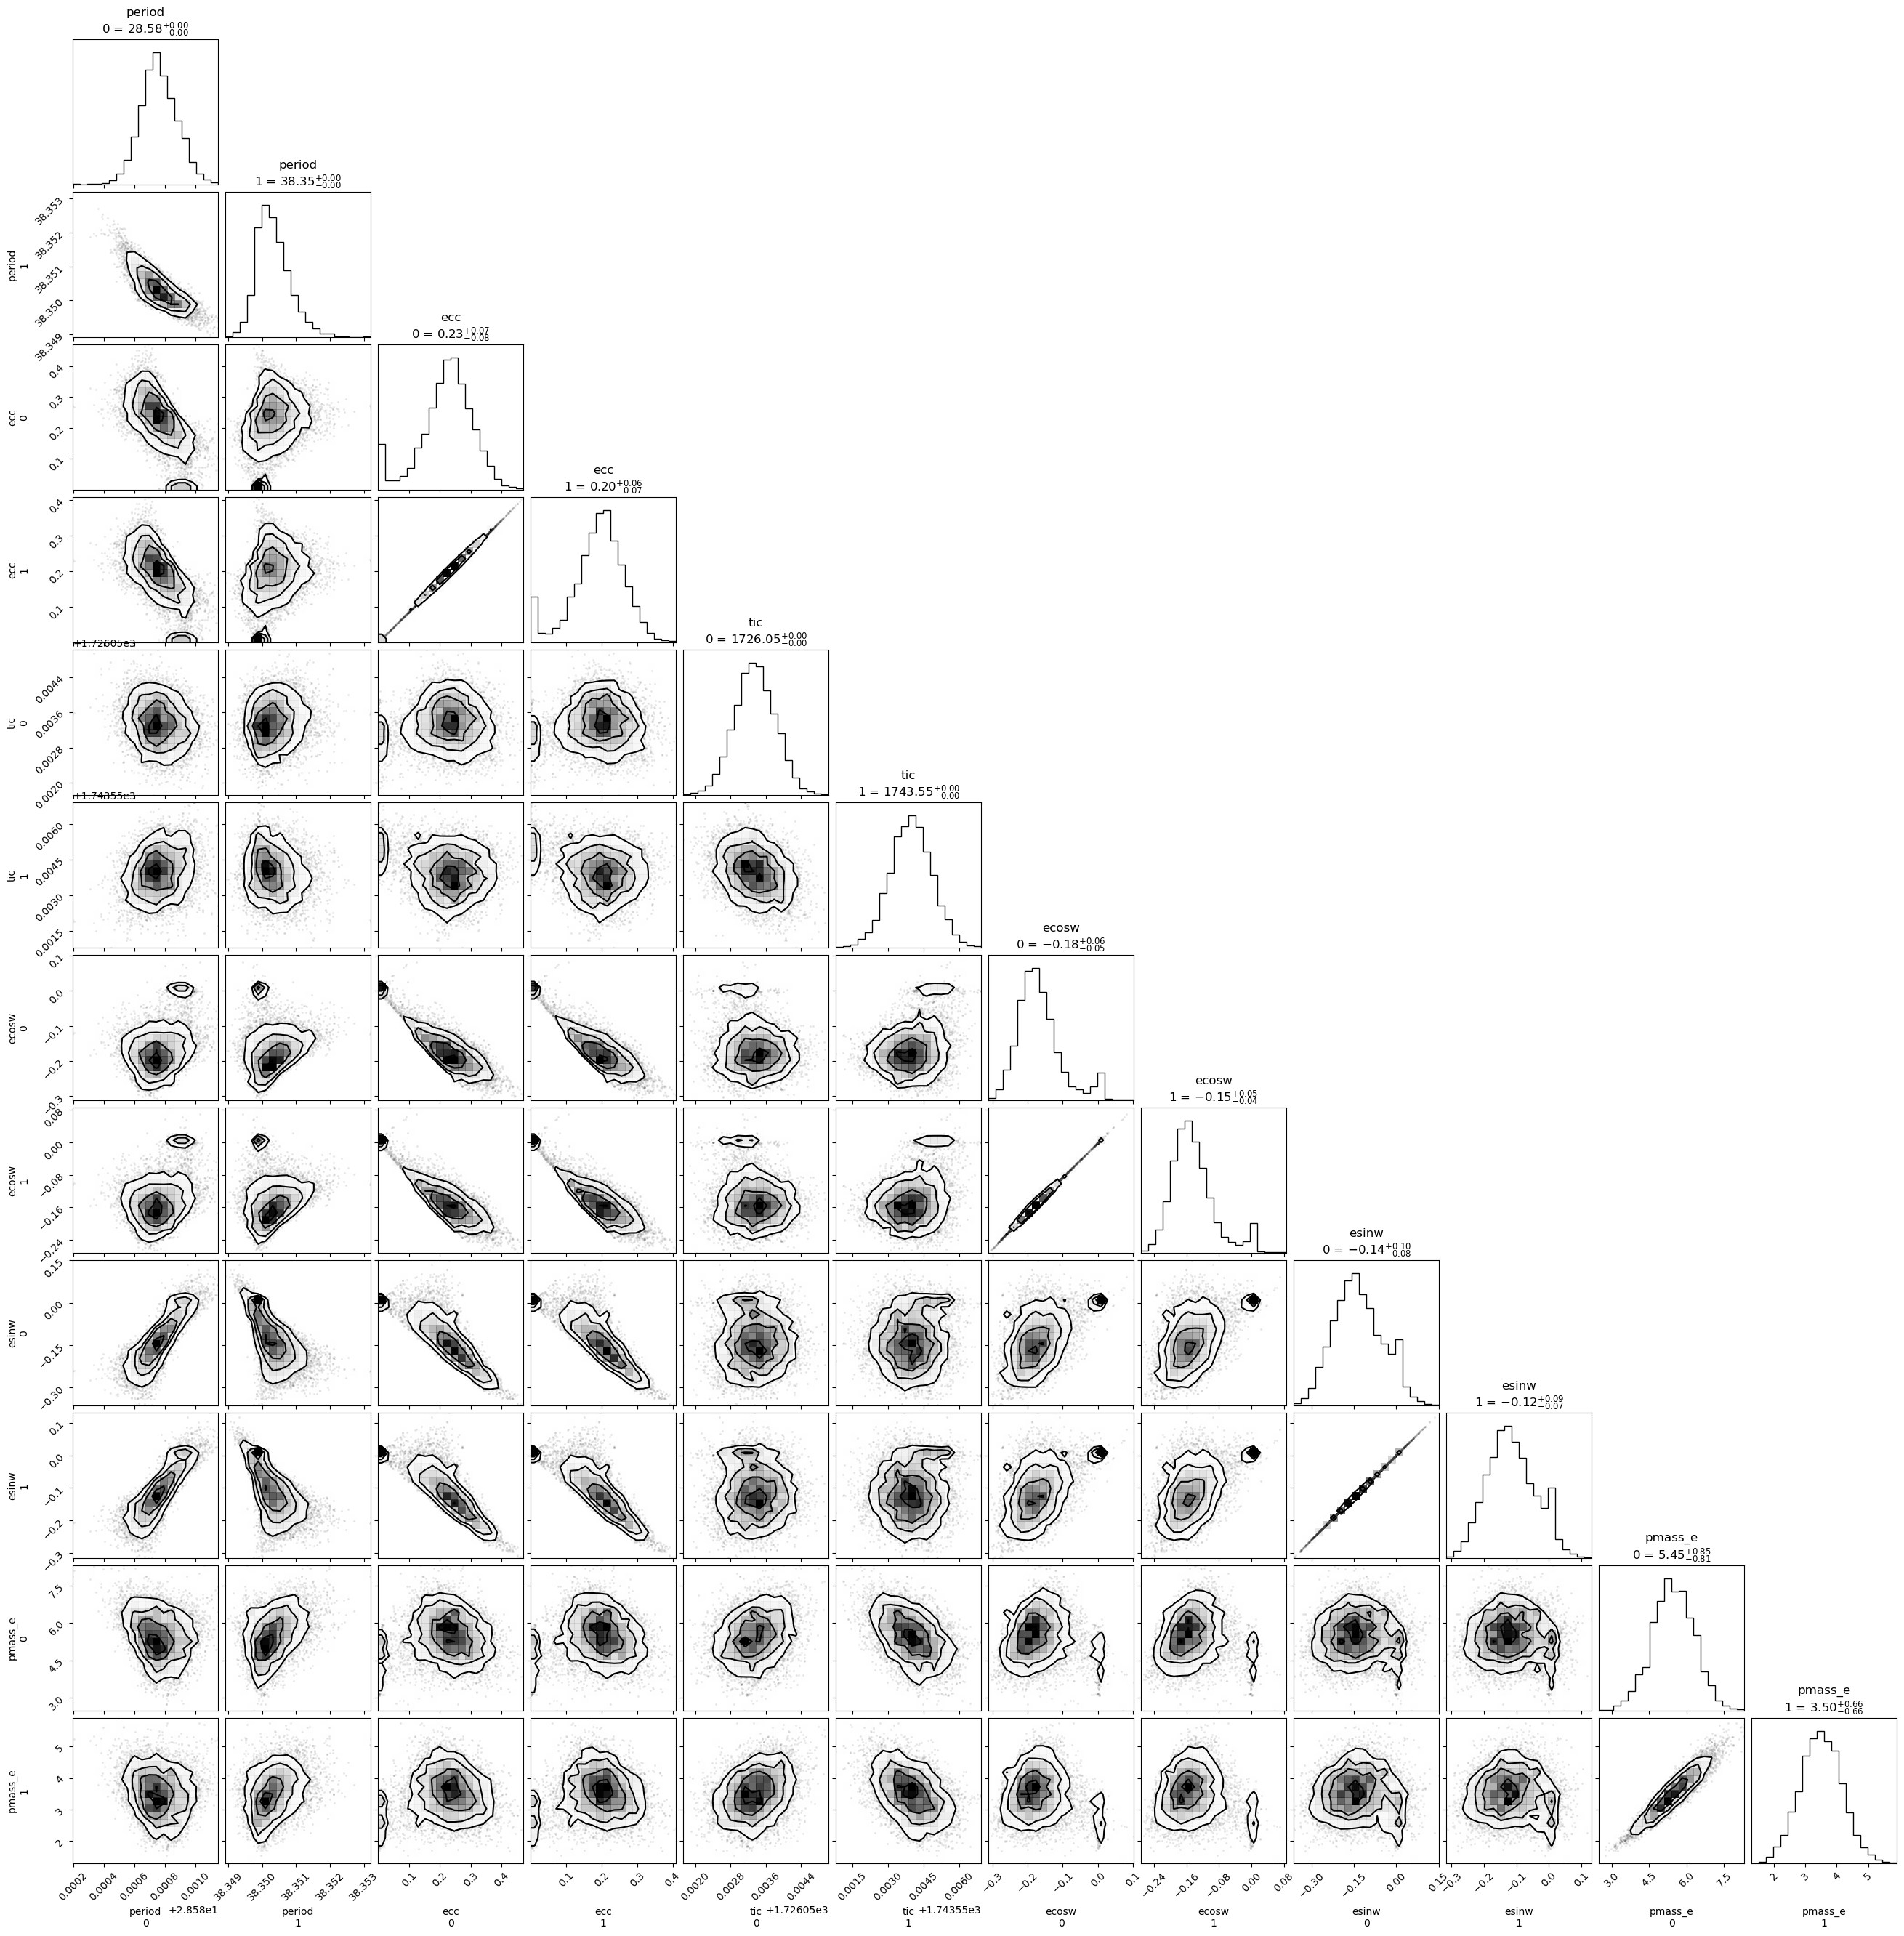

In [25]:
idata_filtered.posterior['pmass_e'] = idata_filtered.posterior['pmass'] / 3.003e-6
names = ["period", "ecc", "tic", "ecosw", "esinw", "pmass_e"]
fig = corner.corner(idata_filtered, var_names=names, show_titles=True)

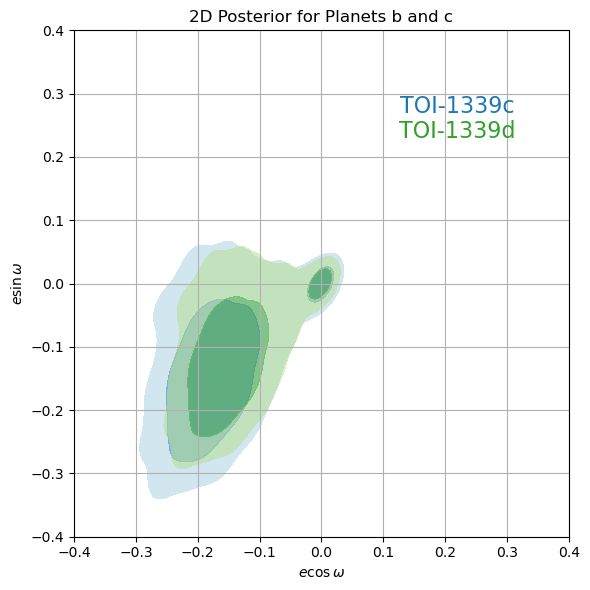

In [26]:
### 2D posterior for ecosw and esinw 
ecosw_b = samples_flat["ecosw"][:, 0]
esinw_b = samples_flat["esinw"][:, 0]

ecosw_c = samples_flat["ecosw"][:, 1]
esinw_c = samples_flat["esinw"][:, 1]

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde


def compute_kde_contour_levels(x, y, gridsize=100):
    data = np.vstack([x, y])
    kde = gaussian_kde(data)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    X, Y = np.mgrid[x_min:x_max:gridsize*1j, y_min:y_max:gridsize*1j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)
    return X, Y, Z, kde

def get_sigma_contour_levels(Z):
    Z_flat = Z.flatten()
    Z_sorted = np.sort(Z_flat)[::-1]
    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]
    levels = []
    for sigma in [0.683, 0.954]:
        idx = np.searchsorted(cumsum, sigma)
        levels.append(Z_sorted[idx])
    return sorted(levels)  # ensures ascending order

# Compute KDEs
Xb, Yb, Zb, kde_b = compute_kde_contour_levels(ecosw_b, esinw_b)
Xc, Yc, Zc, kde_c = compute_kde_contour_levels(ecosw_c, esinw_c)

# Get contour levels
levels_b = get_sigma_contour_levels(Zb)
levels_c = get_sigma_contour_levels(Zc)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Filled contours for planet b (blue shades)
ax.contourf(Xb, Yb, Zb, levels=levels_b + [Zb.max()], colors=['#a6cee3', '#1f78b4'], alpha=0.5)

# Filled contours for planet c (green shades)
ax.contourf(Xc, Yc, Zc, levels=levels_c + [Zc.max()], colors=['#b2df8a', '#33a02c'], alpha=0.5)

# Text annotation
ax.text(0.22, 0.27, 'TOI-1339c', color='#1f78b4', fontsize=16, ha='center')
ax.text(0.22, 0.23, 'TOI-1339d', color='#33a02c', fontsize=16, ha='center')


# Labels and legend
ax.set_xlabel(r"$e \cos\omega$")
ax.set_ylabel(r"$e \sin\omega$")
ax.set_title("2D Posterior for Planets b and c")
blue_patch = plt.Line2D([], [], color='#a6cee3', label='Planet b')
red_patch = plt.Line2D([], [], color='#b2df8a', label='Planet c')
# ax.legend(handles=[blue_patch, red_patch])

plt.grid(True)
plt.xlim(-0.40,0.40)
plt.ylim(-0.40,0.40)
plt.tight_layout()
plt.show()

In [27]:
az.summary(idata_filtered, var_names=["ecc","ecosw_scaled","esinw_scaled", "pmass_scaled","period_scaled","tic_scaled"], round_to=3)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ecc[0],0.222,0.085,0.000,0.342,0.004,0.004,573.890,212.646,1.004
ecc[1],0.191,0.073,0.000,0.295,0.003,0.004,572.092,212.029,1.004
ecosw_scaled[0],0.337,0.063,0.250,0.506,0.003,0.003,577.365,206.282,1.008
ecosw_scaled[1],0.360,0.054,0.285,0.505,0.003,0.003,578.541,206.282,1.008
esinw_scaled[0],0.371,0.086,0.218,0.522,0.003,0.001,853.146,1489.122,1.002
esinw_scaled[1],0.390,0.074,0.258,0.521,0.003,0.001,853.670,1471.432,1.002
pmass_scaled[0],0.016,0.003,0.012,0.021,0.000,0.000,1434.172,1231.270,1.001
pmass_scaled[1],0.010,0.002,0.007,0.014,0.000,0.000,1386.108,951.689,1.001
period_scaled[0],0.502,0.000,0.502,0.502,0.000,0.000,1327.921,2788.502,1.002
period_scaled[1],0.500,0.001,0.499,0.502,0.000,0.000,1484.067,2653.696,1.002


In [28]:
### posterior samples 
ecosw_b = samples_flat["ecosw"][:, 0]
esinw_b = samples_flat["esinw"][:, 0]
Per_b = samples_flat["period"][:,0] # [days]
Tc_b = samples_flat["tic"][:,0] # [days]
pmass_b = samples_flat["pmass"][:, 0] # [solar mass]

ecosw_c = samples_flat["ecosw"][:, 1]
esinw_c = samples_flat["esinw"][:, 1]
Per_c = samples_flat["period"][:,1] # [days]
Tc_c = samples_flat["tic"][:,1] # [days]
pmass_c = samples_flat["pmass"][:, 1] # [solar mass]

### convert planet mass from solar to earth masses 
import astropy.constants as u
convert = (u.M_sun / u.M_earth).value
pmass_earth_b = pmass_b * convert
pmass_earth_c = pmass_c * convert


# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_b = np.sqrt(ecosw_b**2 + esinw_b**2)
omega_rad_b = np.arctan2(esinw_b, ecosw_b)
omega_deg_b = np.rad2deg(omega_rad_b)

# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_c = np.sqrt(ecosw_c**2 + esinw_c**2)
omega_rad_c = np.arctan2(esinw_c, ecosw_c)
omega_deg_c = np.rad2deg(omega_rad_c)


### keep Omega constant
value_Omega_b = 0  # [deg]
Omega_b = [np.radians(value_Omega_b)] * len(omega_rad_b)  # [rad]
value_Omega_c = 0 # [deg]
Omega_c = [np.radians(value_Omega_c)] * len(omega_rad_c)  # [rad]

pomega_rad_b = omega_rad_b + Omega_b
pomega_rad_c = omega_rad_c + Omega_c


Delta_omega_rad = omega_rad_c - omega_rad_b
Delta_omega_deg = omega_deg_c - omega_deg_b

In [45]:
print(np.median(ecc_b))
print(np.median(omega_rad_b))
print(np.median(ecc_c))
print(np.median(omega_rad_c))

print(np.max(ecc_b))
print(np.min(ecc_c))
print(np.max(omega_rad_b))
print(np.min(omega_rad_b))

0.22946261745830493
-2.4036098877536087
0.19704224787256416
-2.4051062469243005
0.4698907675132994
7.939183995815374e-05
3.1406592250841774
-3.1407157412221527


# Investigate two eccentricity modes

/opt/homebrew/anaconda3/lib/python3.12/site-packages/jnkepler/jaxttv/jaxttv.py:523: UserWarning: using t0 and P from a linear fit to the observed transit times.
  warnings.warn(


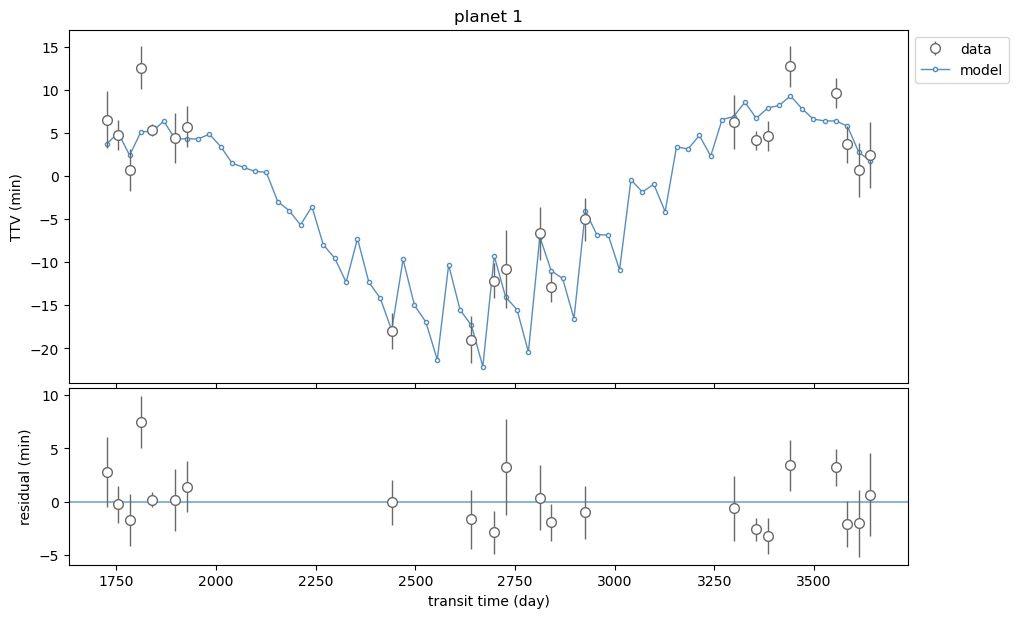

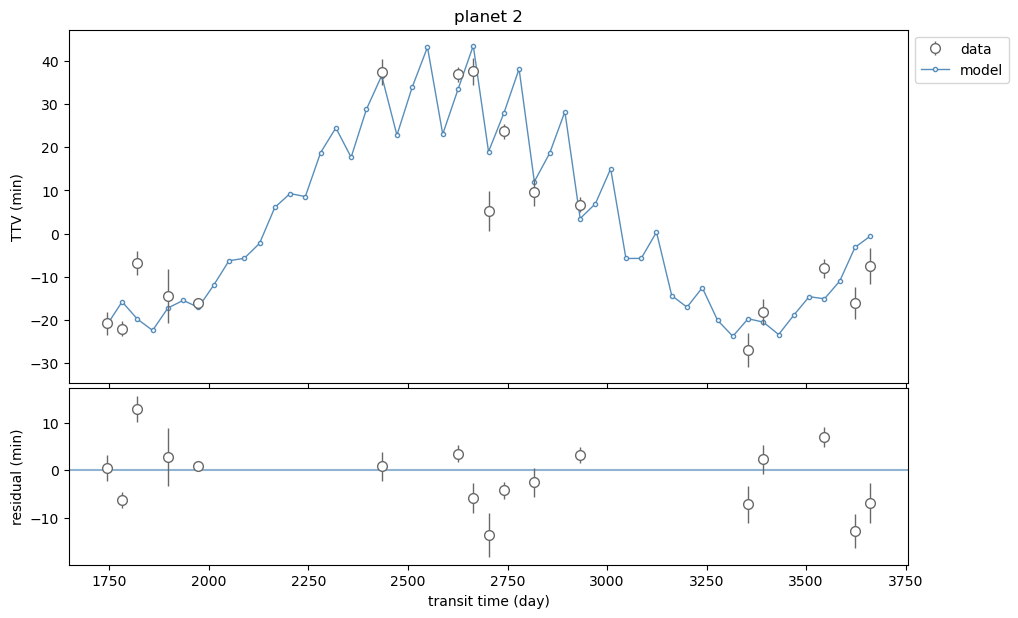

In [29]:
# Your target mode center (e.g., from visual inspection)
target_ecosw = -0.15
target_esinw = -0.17

# Compute distances from each sample
distances = np.sqrt((ecosw_b - target_ecosw)**2 + (esinw_b - target_esinw)**2)

# Find closest sample
closest_idx = np.argmin(distances)

sample_dict = {
    'period': samples_flat['period'][closest_idx],
    'ecosw': samples_flat['ecosw'][closest_idx],
    'esinw': samples_flat['esinw'][closest_idx],
    'tic': samples_flat['tic'][closest_idx],
    'pmass': samples_flat['pmass'][closest_idx],
}
# sample_dict['pmass'] = np.exp(sample_dict['lnpmass'])

tcall = jttv.get_transit_times_all_list(sample_dict)

# Plot the model
jttv.plot_model(tcall, marker='.')
plt.show()

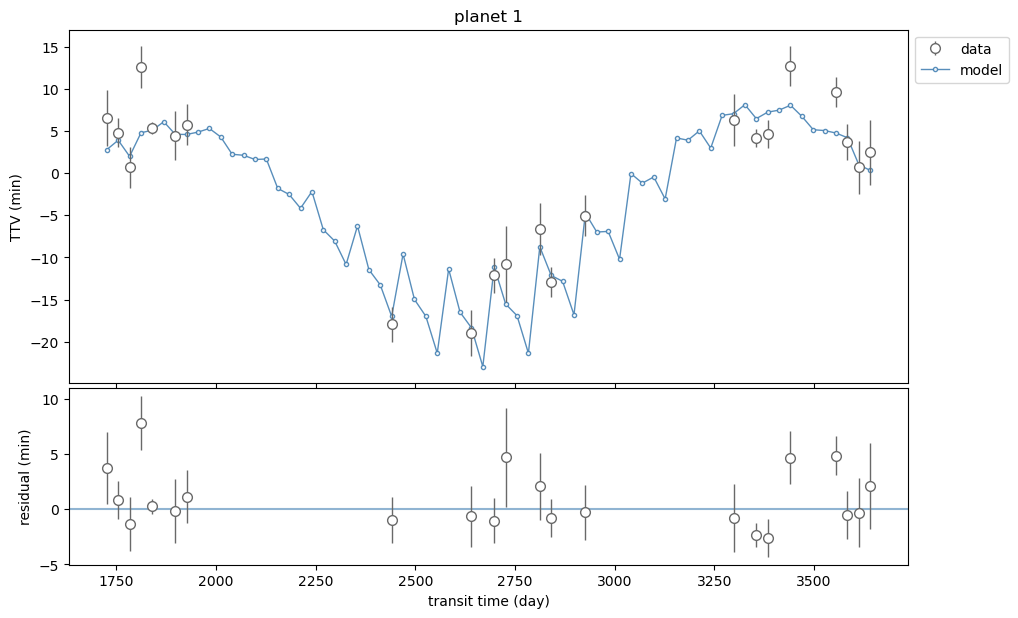

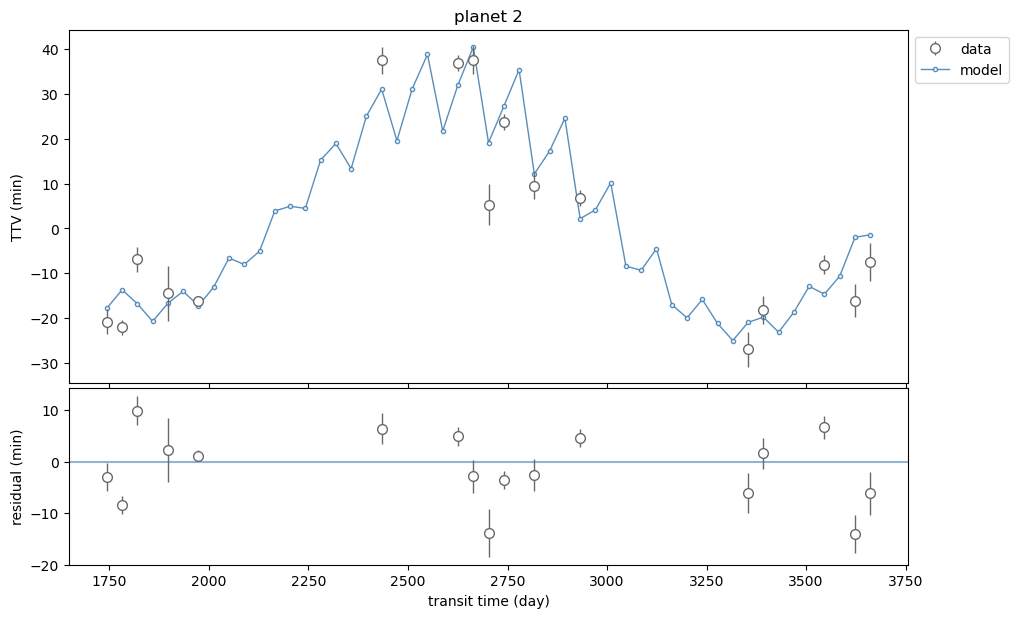

In [30]:
# Your target mode center (e.g., from visual inspection)
target_ecosw = 0.01
target_esinw = 0.01

# Compute distances from each sample
distances = np.sqrt((ecosw_b - target_ecosw)**2 + (esinw_b - target_esinw)**2)

# Find closest sample
closest_idx_2 = np.argmin(distances)

sample_dict = {
    'period': samples_flat['period'][closest_idx_2],
    'ecosw': samples_flat['ecosw'][closest_idx_2],
    'esinw': samples_flat['esinw'][closest_idx_2],
    'tic': samples_flat['tic'][closest_idx_2],
    'pmass': samples_flat['pmass'][closest_idx_2],
}
# sample_dict['pmass'] = np.exp(sample_dict['lnpmass'])

tcall = jttv.get_transit_times_all_list(sample_dict)

# Plot the model
jttv.plot_model(tcall, marker='.')
plt.show()

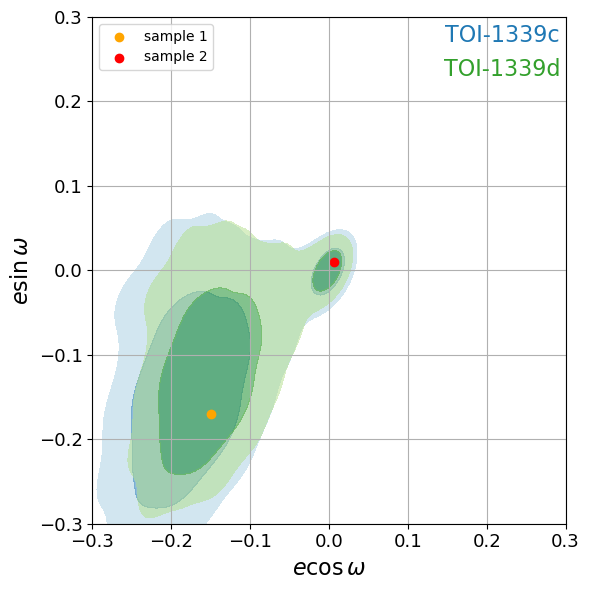

In [31]:
# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Filled contours for planet b (blue shades)
ax.contourf(Xb, Yb, Zb, levels=levels_b + [Zb.max()], colors=['#a6cee3', '#1f78b4'], alpha=0.5)

# Filled contours for planet c (green shades)
ax.contourf(Xc, Yc, Zc, levels=levels_c + [Zc.max()], colors=['#b2df8a', '#33a02c'], alpha=0.5)

# Text annotation
ax.text(0.22, 0.27, 'TOI-1339c', color='#1f78b4', fontsize=16, ha='center')
ax.text(0.22, 0.23, 'TOI-1339d', color='#33a02c', fontsize=16, ha='center')


# Labels and legend
ax.set_xlabel(r"$e \cos\omega$", fontsize=16)
ax.set_ylabel(r"$e \sin\omega$", fontsize=16)
# ax.set_title("2D Joint Posterior of $e  cos(\omega)$ and $e sin(\omega)$")
blue_patch = plt.Line2D([], [], color='#a6cee3', label='Planet b')
red_patch = plt.Line2D([], [], color='#b2df8a', label='Planet c')
# ax.legend(handles=[blue_patch, red_patch])
ax.scatter(ecosw_b[closest_idx],esinw_b[closest_idx], c='orange', label='sample 1')
ax.scatter(ecosw_b[closest_idx_2],esinw_b[closest_idx_2], c='r', label='sample 2')
plt.legend()
# plt.grid(True)
plt.tick_params(axis='both', labelsize=13) 
plt.xlim(-0.30,0.30)
plt.ylim(-0.30,0.30)
plt.grid(True)
plt.tight_layout()
plt.show()

# Constraints on duration

In [35]:
def dur_ratio(b, e, esinw):
    term1 = np.sqrt(1-b**2)
    term2_num = np.sqrt(1-e**2)
    term2_den = 1 + esinw
    term2 = term2_num / term2_den
    dur_rat = term1 * term2
    return dur_rat
    

In [36]:
### from lubin 2022
b_b = 0.63 
b_b_err = 0.02

b_c =  0.48 
b_c_err = 0.04

In [37]:
dur_ratio_b = dur_ratio(b_b, ecc_b, esinw_b)
dur_ratio_c = dur_ratio(b_c, ecc_c, esinw_c)


In [38]:
print(dur_ratio_b)
print(dur_ratio_c)

[1.01419828 0.87935602 0.90827896 ... 0.73530167 0.80593084 0.90744429]
[1.10636357 0.97725213 1.0057392  ... 0.83672943 0.9054128  1.00668317]
